<h1 ><big><center>Object recognition and computer vision 2023/2024</center></big></h1>

<h3><big><center><a href="http://imagine.enpc.fr/~varolg/">Gül Varol</a>, <a href="http://www.di.ens.fr/~ponce/">Jean Ponce</a>, <a href="https://scholar.google.fr/citations?user=kRJkDakAAAAJ">Armand Joulin</a>,  <a href="http://www.di.ens.fr/~josef/">Josef Sivic</a>, <a href="http://www.di.ens.fr/~laptev/">Ivan Laptev</a>, <a href="http://lear.inrialpes.fr/~schmid/">Cordelia Schmid</a> and <a href="http://imagine.enpc.fr/~aubrym/">Mathieu Aubry</a></center></big></h3>


<h2><big><center> Assignment 2: Neural networks</center></big></h2>

<h5><big><center>Adapted from practicals from <a href="http://nicolas.le-roux.name/">Nicolas le Roux</a>,
  <br><a href="http://www.robots.ox.ac.uk/~vgg/practicals/overview/index.html">Andrea Vedaldi and Andrew Zisserman</a> and <a href="https://cs.nyu.edu/~fergus/teaching/vision/">Rob Fergus</a>
  <br> by <a href="https://www.di.ens.fr/~varol/">Gul Varol</a> and <a href="https://www.di.ens.fr/~iroccosp/">Ignacio Rocco</a></center></big></h5>


</br>

<p align="center">
<img height=300px src="http://www.di.ens.fr/willow/teaching/recvis_orig/assignment3/images/fullyconn.png"/></p>
<p align="center">Figure 1</p>
<p align="center"></p>



```
# Ce texte est au format code
```

**STUDENT**:  RAMI Ilias

**EMAIL**:  ilias.rami@ens-paris-saclay.fr

# Guidelines

The purpose of this assignment is that you get hands-on experience with the topics covered in class, which will help you understand these topics better. Therefore, ** it is imperative that you do this assignment yourself. No code sharing will be tolerated. **

Once you have completed the assignment, you will submit the `ipynb` file containing **both** code and results. For this, make sure to **run your notebook completely before submitting**.

The `ipynb` must be named using the following format: **A2_LASTNAME_Firstname.ipynb**, and submitted in the **class Moodle page**.

# Goal


The goal of this assignment is to get basic knowledge and hands-on experience with training and using neural networks. In Part 1 of the assignment you will implement and experiment with the training and testing of a simple two layer fully-connected neural network, similar to the one depicted in Figure 1 above. In Part 2 you will learn about convolutional neural networks, their motivation, building blocks, and how they are trained. Finally, in part 3 you will train a CNN for classification using the CIFAR-10 dataset.

# Part 1 - Training a fully connected neural network

## Getting started

You will be working with a two layer neural network of the following form

\begin{equation}
H=\text{ReLU}(W_i X+B_i)\\
Y=W_oH+B_o
\tag{1}
\end{equation}

where $X$ is the input, $Y$ is the output, $H$ is the hidden layer, and $W_i$, $W_o$, $B_i$ and $B_o$ are the network parameters that need to be trained. Here the subscripts $i$ and $o$ stand for the *input* and *output* layer, respectively. This network was also discussed in the class and is illustrated in the above figure where the input units are shown in green, the hidden units in blue and the output in yellow. This network is implemented in the function `nnet_forward_logloss`.

You will train the parameters of the network from labelled training data $\{X^n,Y^n\}$ where $X^n$ are points in $\mathbb{R}^2$ and $Y^n\in\{-1,1\}$ are labels for each point. You will use the stochastic gradient descent algorithm discussed in the class to minimize the loss of the network on the training data given by

\begin{equation}
L=\sum_n s(Y^n,\bar{Y}(X^n))
\tag{2}
\end{equation}

where $Y^n$ is the target label for the n-th example and $\bar{Y}(X^n)$ is the network’s output for the n-th example $X^n$. The skeleton of the training procedure is provided in the `train_loop` function.

We will use the logistic loss, which has the following form:

\begin{equation}
s(Y, \bar{Y}(X))=\log(1+\exp(-Y. \bar{Y}(X))
\tag{3}
\end{equation}

where $Y$ is the target label and $\bar{Y}(X)$ is the output of the network for input example $X$. With the logistic loss, the output of the network can be interpreted as a probability $P(\text{class}=1|X) =\sigma(X)$ , where $\sigma(X) =1/(1+\exp(-X))$ is the sigmoid function. Note also that $P(\text{class}=-1|X)=1-P(\text{class}=1|X)$.

In [ ]:
from IPython import display
import matplotlib.pyplot as plt
import numpy as np
import scipy.io as sio


def decision_boundary_nnet(X, Y, Wi, bi, Wo, bo):
    x_min, x_max = -2, 4
    y_min, y_max = -5, 3
    xx, yy = np.meshgrid(np.arange(x_min, x_max, .05),
                     np.arange(y_min, y_max, .05))

    XX = np.vstack((xx.ravel(), yy.ravel())).T
    input_hidden = np.dot(XX, Wi) + bi
    hidden = np.maximum(input_hidden, 0)
    Z = np.dot(hidden, Wo) + bo

    # Put the result into a color plot
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z > 0, cmap=plt.cm.Paired)
    plt.axis('off')

    # Plot also the training points
    plt.scatter(X[:, 0], X[:, 1], c=Y, cmap='winter')
    plt.axis([-2, 4, -5, 3])
    plt.draw()


def sigm(x):
    # Returns the sigmoid of x.
    small_x = np.where(x < -20)  # Avoid overflows.
    sigm_x = 1/(1 + np.exp(-x))
    if type(sigm_x) is np.ndarray:
        sigm_x[small_x] = 0.0
    return sigm_x


def nnet_forward_logloss(X, Y, Wi, bi, Wo, bo):
    '''
    Compute the output Po, Yo and the loss of the network for the input X
    This is a 2 layer (1 hidden layer network)

    Input:
        X ... (in R^2) set of input points, one per column
        Y ... {-1,1} the target values for the set of points X
        Wi, bi, Wo, bo ... parameters of the network

    Output:
       Po ... probabilisitc output of the network P(class=1 | x)
                  Po is in <0 1>.
                  Note: P(class=-1 | x ) = 1 - Po
       Yo ... output of the network Yo is in <-inf +inf>
       loss ... logistic loss of the network on examples X with ground target
                    values Y in {-1,1}
    '''
    # Hidden layer
    hidden = np.maximum(np.dot(X, Wi) + bi, 0)
    # Output of the network
    Yo = np.dot(hidden, Wo) + bo
    # Probabilistic output
    Po = sigm(Yo)
    # Logistic loss
    loss = np.log(1 + np.exp( -Y * Yo))
    return Po, Yo, loss


# Load the training data
!wget -q http://www.di.ens.fr/willow/teaching/recvis_orig/assignment2/double_moon_train1000.mat
train_data = sio.loadmat('./double_moon_train1000.mat', squeeze_me=True)
Xtr = train_data['X']
Ytr = train_data['Y']
# Load the validation data
!wget -q http://www.di.ens.fr/willow/teaching/recvis_orig/assignment2/double_moon_val1000.mat
val_data = sio.loadmat('./double_moon_val1000.mat', squeeze_me=True)
Xval = val_data['X']
Yval = val_data['Y']

## Computing gradients of the loss with respect to network parameters

### :: TASK 1.1 ::
Derive the form of the gradient of the logistic loss (3) with respect to the parameters of the network $W_i$, $W_o$, $B_i$ and $B_o$.  *Hint:* Use the chain rule as discussed in the class.

We have:
$$
s(Y, \bar{Y}(X)) = \log(1 + \exp(-Y \cdot \bar{Y}(X)))
$$

where $$\bar{Y}(X) = W_o H + B_o $$\&$$   H = \text{RELU}(W_i X + B_i)$$

1. **Gradient with respect to \(W_i\):**

$$\frac{\partial s(Y, \bar{Y}(X))}{\partial W_i} = \frac{\partial s(Y, \bar{Y}(X))}{\partial H} \cdot \frac{\partial H}{\partial W_i} = \frac{\partial s(Y, \bar{Y}(X))}{\partial \bar{Y}} \cdot \frac{\partial \bar{Y}}{\partial H} \cdot \frac{\partial H}{\partial W_i}\$$

Calculating each term separately:

$$
\frac{\partial s(Y, \bar{Y}(X))}{\partial \bar{Y}} = \frac{\partial \log(1 + \exp(-Y \cdot \bar{Y}(X)))}{\partial \bar{Y}} = \frac{-Y \cdot \exp(-Y \cdot \bar{Y}(X))}{1 + \exp(-Y \cdot \bar{Y}(X))} = \frac{-Y}{1 + \exp(Y \cdot \bar{Y}(X))}
$$

$$
\frac{\partial \bar{Y}}{\partial H} = W_o
$$

$$
\frac{\partial H}{\partial W_i} = \frac{\partial \, \text{RELU}(W_i X + B_i)}{\partial W_i} = \frac{\partial \, \max(0, W_i X + B_i)}{\partial W_i} = \begin{cases} X^T & \text{if } W_i X + B_i > 0 \\ 0 & \text{otherwise} \end{cases}
$$

Thus:

$$
\boxed{
\frac{\partial s(Y, \bar{Y}(X))}{\partial W_i} =
\begin{cases}
\frac{-Y}{1 + \exp(Y \cdot \bar{Y}(X))} \cdot W_o \cdot X^T & \text{if } W_i X + B_i > 0 \\
0 & \text{otherwise}
\end{cases}=\begin{cases}
-Y\cdot\sigma(-Y \cdot \bar{Y}(X)) \cdot W_o \cdot X^T & \text{if } W_i X + B_i > 0 \\
0 & \text{otherwise}
\end{cases}
}
$$


2. **Gradient with respect to \(W_o\):**

$$
\frac{\partial s(Y, \bar{Y}(X))}{\partial W_o} = \frac{\partial s(Y, \bar{Y}(X))}{\partial \bar{Y}} \cdot \frac{\partial \bar{Y}}{\partial W_o} = \frac{-Y}{1 + \exp(Y \cdot \bar{Y}(X))} \cdot H
$$

Therefore:

$$
\boxed{\frac{\partial s(Y, \bar{Y}(X))}{\partial W_o} = \frac{-Y}{1 + \exp(Y \cdot \bar{Y}(X))} \cdot H=-Y \cdot \sigma(-Y \cdot \bar{Y}(X))\cdot H}
$$


3. **Gradient with respect to \(B_i\):**

$$
\frac{\partial s(Y, \bar{Y}(X))}{\partial B_i} = \frac{\partial s(Y, \bar{Y}(X))}{\partial H} \cdot \frac{\partial H}{\partial B_i} = \frac{\partial s(Y, \bar{Y}(X))}{\partial \bar{Y}} \cdot \frac{\partial \bar{Y}}{\partial H} \cdot \frac{\partial H}{\partial B_i}
$$

where:

$$
\frac{\partial H}{\partial B_i} = \frac{\partial \, \text{RELU}(W_i X + B_i)}{\partial B_i} = \frac{\partial \, \max(0, W_i X + B_i)}{\partial B_i} = \begin{cases} 1 & \text{if } W_i X + B_i > 0 \\ 0 & \text{otherwise} \end{cases}
$$

Thus:

$$
\boxed{\frac{\partial s(Y, \bar{Y}(X))}{\partial B_i} = \begin{cases} \frac{-Y}{1 + \exp(Y \cdot \bar{Y}(X))} \cdot W_o & \text{if } W_i X + B_i > 0 \\ 0 & \text{otherwise} \end{cases}= \begin{cases} -Y\cdot\sigma(-Y \cdot \bar{Y}(X))  \cdot W_o & \text{if } W_i X + B_i > 0 \\ 0 & \text{otherwise} \end{cases}}
$$


4. **Gradient with respect to \(B_o\):**

$$
\frac{\partial s(Y, \bar{Y}(X))}{\partial B_o} = \frac{\partial s(Y, \bar{Y}(X))}{\partial \bar{Y}} \cdot \frac{\partial \bar{Y}}{\partial B_o} = \frac{-Y}{1 + \exp(Y \cdot \bar{Y}(X))}
$$

So:

$$
\boxed{\frac{\partial s(Y, \bar{Y}(X))}{\partial B_o} = \frac{-Y}{1 + \exp(Y \cdot \bar{Y}(X))}=-Y\cdot\sigma(-Y \cdot \bar{Y}(X)) }
$$





### :: TASK 1.2 ::

Following your derivation, implement the gradient computation in the function `gradient_nn`. See the code for the description of the required inputs / outputs of this function.

In [ ]:
def gradient_nn(X, Y, Wi, bi, Wo, bo):
    '''
    Compute gradient of the logistic loss of the neural network on example X with
    target label Y, with respect to the parameters Wi,bi,Wo,bo.

    Input:
        X ... 2d vector of the input example
        Y ... the target label in {-1,1}
        Wi,bi,Wo,bo ... parameters of the network
        Wi ... [dxh]
        bi ... [h]
        Wo ... [h]
        bo ... 1
        where h... is the number of hidden units
              d... is the number of input dimensions (d=2)

    Output:
        grad_s_Wi [dxh] ... gradient of loss s(Y,Y(X)) w.r.t  Wi
        grad_s_bi [h]   ... gradient of loss s(Y,Y(X)) w.r.t. bi
        grad_s_Wo [h]   ... gradient of loss s(Y,Y(X)) w.r.t. Wo
        grad_s_bo 1     ... gradient of loss s(Y,Y(X)) w.r.t. bo
    '''

    ##########################
    # Compute hidden layer activation
    H = np.maximum(np.dot(X, Wi) + bi, 0)  # ReLU activation

    # Compute the output prediction
    Y_bar = np.dot(H, Wo) + bo

    # Compute common term for gradients, which depends on the sigmoid derivative
    common_term = -Y * sigm(-Y * Y_bar)

    # Compute the gradients for each parameter
    # Gradient with respect to Wi
    grad_s_Wi = (common_term * np.dot(np.array(X).reshape(X.shape[0], 1), np.array(Wo).reshape(1, Wo.shape[0])) *
                np.maximum(np.dot(X, Wi) + bi, 0) / (np.dot(X, Wi) + bi))

    # Gradient with respect to Wo
    grad_s_Wo = common_term * H

    # Gradient with respect to bo (output bias)
    grad_s_bo = common_term

    # Gradient with respect to bi (hidden layer bias)
    grad_s_bi = (common_term * Wo * np.maximum(np.dot(X, Wi) + bi, 0) / (np.dot(X, Wi) + bi))

    return grad_s_Wi, grad_s_bi, grad_s_Wo, grad_s_bo

    ##########################

## Numerically verify the gradients
Here you will numerically verify that your analytically computed gradients in function `gradient_nn` are correct.

### :: TASK 1.3 ::
Write down the general formula for numerically computing the approximate derivative of the loss $s(\theta)$, with respect to the parameter $\theta_i$ using finite differencing.  *Hint: use the first order Taylor expansion of loss $s(\theta+\Delta \theta)$ around point $\theta$. *

######################

Denote by $ J(\theta) $ the gradient of $s$ with respect $ \theta $ . Using Taylor expansion formula for small $ \Delta \theta $ we can write:
$$  s(\theta + \Delta \theta) \approx s(\theta) +\frac{\partial s(\theta)}{\partial \theta} \Delta \theta $$
$$  s(\theta - \Delta \theta) \approx s(\theta) - \frac{\partial s(\theta)}{\partial \theta} \Delta \theta $$
Thus
$$  2\frac{\partial s(\theta)}{\partial \theta} \Delta \theta \approx s(\theta + \Delta \theta) - s(\theta - \Delta \theta)  $$
Thus component wise we can finally use the following numerical approximation using $e_i$ as the i-th column of the identity matrix

$$  J(\theta_i) \approx\frac{ s(\theta_i + \Delta \theta_i e_i) - s(\theta_i - \Delta \theta_i e_i)}{2\Delta \theta_i} $$

######################

Following the general formula, `gradient_nn_numerical` function numerically computes the derivatives of the loss function with respect to all the parameters of the network $W_i$, $W_o$, $B_i$ and $B_o$:

In [ ]:
def gradient_nn_numerical(X, Y, Wi, bi, Wo, bo):
    '''
    Compute numerical gradient of the logistic loss of the neural network on
    example X with target label Y, with respect to the parameters Wi,bi,Wo,bo.

    Input:
       X ... 2d vector of the input example
       Y ... the target label in {-1,1}
       Wi, bi, Wo, bo ... parameters of the network
       Wi ... [dxh]
       bi ... [h]
       Wo ... [h]
       bo ... 1
       where h... is the number of hidden units
             d... is the number of input dimensions (d=2)

    Output:
       grad_s_Wi_numerical [dxh] ... gradient of loss s(Y,Y(X)) w.r.t  Wi
       grad_s_bi_numerical [h]   ... gradient of loss s(Y,Y(X)) w.r.t. bi
       grad_s_Wo_numerical [h]   ... gradient of loss s(Y,Y(X)) w.r.t. Wo
       grad_s_bo_numerical 1     ... gradient of loss s(Y,Y(X)) w.r.t. bo
    '''

    eps = 1e-8
    grad_s_Wi_numerical = np.zeros(Wi.shape)
    grad_s_bi_numerical = np.zeros(bi.shape)
    grad_s_Wo_numerical = np.zeros(Wo.shape)

    for i in range(Wi.shape[0]):
        for j in range(Wi.shape[1]):
            dummy, dummy, pos_loss = nnet_forward_logloss(X, Y, sumelement_matrix(Wi, i, j, +eps), bi, Wo, bo)
            dummy, dummy, neg_loss = nnet_forward_logloss(X, Y, sumelement_matrix(Wi, i, j, -eps), bi, Wo, bo)
            grad_s_Wi_numerical[i, j] = (pos_loss - neg_loss)/(2*eps)

    for i in range(bi.shape[0]):
        dummy, dummy, pos_loss = nnet_forward_logloss(X, Y, Wi, sumelement_vector(bi, i, +eps), Wo, bo)
        dummy, dummy, neg_loss = nnet_forward_logloss(X, Y, Wi, sumelement_vector(bi, i, -eps), Wo, bo)
        grad_s_bi_numerical[i] = (pos_loss - neg_loss)/(2*eps)

    for i in range(Wo.shape[0]):
        dummy, dummy, pos_loss = nnet_forward_logloss(X, Y, Wi, bi, sumelement_vector(Wo, i, +eps), bo)
        dummy, dummy, neg_loss = nnet_forward_logloss(X, Y, Wi, bi, sumelement_vector(Wo, i, -eps), bo)
        grad_s_Wo_numerical[i] = (pos_loss - neg_loss)/(2*eps)

    dummy, dummy, pos_loss = nnet_forward_logloss(X, Y, Wi, bi, Wo, bo+eps)
    dummy, dummy, neg_loss = nnet_forward_logloss(X, Y, Wi, bi, Wo, bo-eps)
    grad_s_bo_numerical = (pos_loss - neg_loss)/(2*eps)

    return grad_s_Wi_numerical, grad_s_bi_numerical, grad_s_Wo_numerical, grad_s_bo_numerical


def sumelement_matrix(X, i, j, element):
    Y = np.copy(X)
    Y[i, j] = X[i, j] + element
    return Y


def sumelement_vector(X, i, element):
    Y = np.copy(X)
    Y[i] = X[i] + element
    return Y

### :: TASK 1.4 ::

Run the following code snippet and understand what it is doing. `gradcheck` function checks that the analytically computed derivative using function `gradient_nn` (e.g. `grad_s_bo`) at the same training example $\{X,Y\}$ is the same (up to small errors) as your numerically computed value of the derivative using function `gradient_nn_numerical` (e.g. `grad_s_bo_numerical`). Make sure the output is `SUCCESS` to move on to the next task.

In [ ]:
def gradcheck():
    '''
    Check that the numerical and analytical gradients are the same up to eps
    '''
    h = 3 # number of hidden units
    eps = 1e-6
    for i in range(1000):
        # Generate random input/output/weight/bias
        X  = np.random.randn(2)
        Y  = 2* np.random.randint(2) - 1 # {-1, 1}
        Wi = np.random.randn(X.shape[0], h)
        bi = np.random.randn(h)
        Wo = np.random.randn(h)
        bo = np.random.randn(1)
        # Compute analytical gradients
        grad_s_Wi, grad_s_bi, grad_s_Wo, grad_s_bo = gradient_nn(X, Y, Wi, bi, Wo, bo)
        # Compute numerical gradients
        grad_s_Wi_numerical, grad_s_bi_numerical, grad_s_Wo_numerical, grad_s_bo_numerical = gradient_nn_numerical(X, Y, Wi, bi, Wo, bo)
        # Compute the difference between analytical and numerical gradients
        delta_Wi = np.mean(np.abs(grad_s_Wi - grad_s_Wi_numerical))
        delta_bi = np.mean(np.abs(grad_s_bi - grad_s_bi_numerical))
        delta_Wo = np.mean(np.abs(grad_s_Wo - grad_s_Wo_numerical))
        delta_bo = np.abs(grad_s_bo - grad_s_bo_numerical)
        # Difference larger than a threshold
        if ( delta_Wi > eps or delta_bi > eps or delta_Wo > eps or delta_bo > eps):
            return False

    return True


# Check gradients
if gradcheck():
    print('SUCCESS: Passed gradcheck.')
else:
    print('FAILURE: Fix gradient_nn and/or gradient_nn_aprox implementation.')

<ipython-input-30-73f95023ff68>:33: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  grad_s_Wi_numerical[i, j] = (pos_loss - neg_loss)/(2*eps)
<ipython-input-30-73f95023ff68>:38: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  grad_s_bi_numerical[i] = (pos_loss - neg_loss)/(2*eps)
<ipython-input-30-73f95023ff68>:43: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  grad_s_Wo_numerical[i] = (pos_loss - neg_loss)/(2*eps)


SUCCESS: Passed gradcheck.


## Training the network using backpropagation and experimenting with different parameters

Use the provided code below that calls the `train_loop` function. Set the number of hidden units to 7 by setting $h=7$ in the code and set the learning rate to 0.02 by setting `lrate = 0.02`. Run the training code. Visualize the trained hyperplane using the provided function `plot_decision_boundary(Xtr,Ytr,Wi,bi,Wo,bo)`. Show also the evolution of the training and validation errors. Include the decision hyper-plane visualization and the training and validation error plots.

In [ ]:
def train_loop(Xtr, Ytr, Xval, Yval, h, lrate, vis='all', nEpochs=100):
    '''
    Check that the numerical and analytical gradients are the same up to eps

    Input:
        Xtr ... Nx2 matrix of training samples
        Ytr ... N dimensional vector of training labels
        Xval ... Nx2 matrix of validation samples
        Yval ... N dimensional vector validation labels
        h ... number of hidden units
        lrate ... learning rate
        vis ... visulaization option ('all' | 'last' | 'never')
        nEpochs ... number of training epochs

    Output:
        tr_error ... nEpochs*nSamples dimensional vector of training error
        val_error ... nEpochs*nSamples dimensional vector of validation error
    '''

    nSamples = Xtr.shape[0]
    tr_error = np.zeros(nEpochs*nSamples)
    val_error = np.zeros(nEpochs*nSamples)

    # Randomly initialize parameters of the model
    Wi = np.random.randn(Xtr.shape[1], h)
    Wo = np.zeros(h)
    bi = np.zeros(h)
    bo = 0.

    if(vis == 'all' or vis == 'last'):
        plt.figure()

    for i in range(nEpochs*nSamples):
        # Draw an example at random
        n = np.random.randint(nSamples)
        X = Xtr[n]
        Y = Ytr[n]

        # Compute gradient
        grad_s_Wi, grad_s_bi, grad_s_Wo, grad_s_bo = gradient_nn(X, Y, Wi, bi, Wo, bo)

        # Gradient update
        Wi -= lrate*grad_s_Wi
        Wo -= lrate*grad_s_Wo
        bi -= lrate*grad_s_bi
        bo -= lrate*grad_s_bo

        # Compute training error
        Po, Yo, loss    = nnet_forward_logloss(Xtr, Ytr, Wi, bi, Wo, bo)
        Yo_class        = np.sign(Yo)
        tr_error[i]     = 100*np.mean(Yo_class != Ytr)

        # Compute validation error
        Pov, Yov, lossv = nnet_forward_logloss(Xval, Yval, Wi, bi, Wo, bo)
        Yov_class       = np.sign(Yov)
        val_error[i]    = 100*np.mean(Yov_class != Yval)

        # Plot (at every epoch if visualization is 'all', only at the end if 'last')
        if(vis == 'all' and i%nSamples == 0) or (vis == 'last' and i == nEpochs*nSamples - 1):
            # Draw the decision boundary.
            plt.clf()
            plt.title('p = %d, Iteration = %.d, Error = %.3f' % (h, i/nSamples, tr_error[i]))
            decision_boundary_nnet(Xtr, Ytr, Wi, bi, Wo, bo)
            display.display(plt.gcf(), display_id=True)
            display.clear_output(wait=True)

    if(vis == 'all'):
        # Plot the evolution of the training and test errors
        plt.figure()
        plt.plot(tr_error, label='training')
        plt.plot(val_error, label='validation')
        plt.legend()
        plt.title('Training/validation errors: %.2f%% / %.2f%%' % (tr_error[-1], val_error[-1]))
    return tr_error, val_error

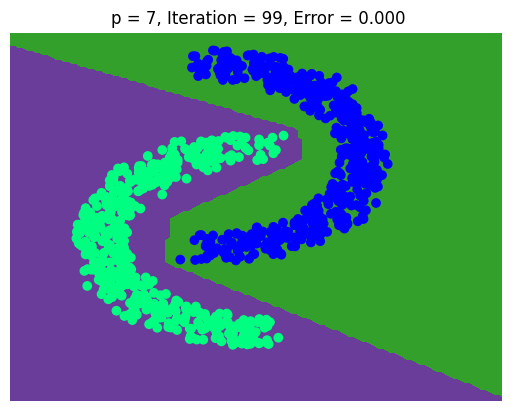

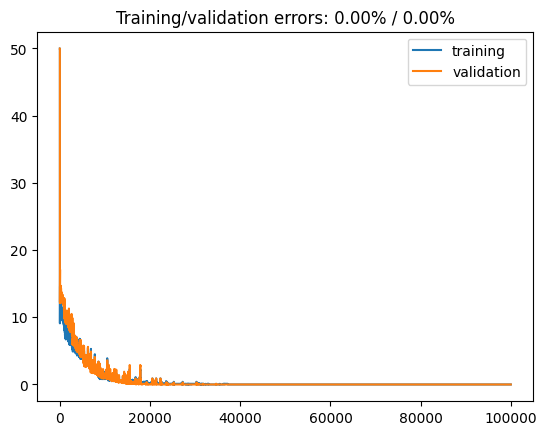

In [ ]:
# Run training
h = 7
lrate = .02
tr_error, val_error = train_loop(Xtr, Ytr, Xval, Yval, h, lrate)

### :: TASK 1.6 ::

**Random initializations.** Repeat this procedure 5 times from 5 different random initializations. Record for each run the final training and validation errors. Did the network always converge to zero training error? Summarize your final training and validation errors into a table for the 5 runs. You do not need to include the decision hyper-plane visualizations. Note: to speed-up the training you can plot the visualization figures less often (or never) and hence speed-up the training.

In [ ]:
##########################

import pandas as pd
import numpy as np

# Set random seed for reproducibility
np.random.seed(123)

# Initialize lists to store training and validation errors
training_errors = []
validation_errors = []

# Run multiple trials
for trial in range(5):
    print(f'Trial {trial + 1}')

    # Run training loop and capture final training and validation errors
    final_train_error, final_val_error = train_loop(Xtr, Ytr, Xval, Yval, h, lrate, vis='never', nEpochs=100)

    # Store the final errors from each trial
    training_errors.append(final_train_error[-1])
    validation_errors.append(final_val_error[-1])

# Create a DataFrame to display results
errors_df = pd.DataFrame({
    'Training Error': training_errors,
    'Validation Error': validation_errors
})

# Show the DataFrame with the errors
print(errors_df)

##########################

Trial 1


<ipython-input-26-04b2a96754fd>:31: DeprecationWarning: Calling nonzero on 0d arrays is deprecated, as it behaves surprisingly. Use `atleast_1d(cond).nonzero()` if the old behavior was intended. If the context of this warning is of the form `arr[nonzero(cond)]`, just use `arr[cond]`.
  small_x = np.where(x < -20)  # Avoid overflows.


Trial 2
Trial 3
Trial 4
Trial 5
   Training Error  Validation Error
0             0.0               0.0
1             0.0               0.0
2             0.0               0.0
3             0.0               0.0
4             0.0               0.0


######################

The algorithm consistently achieves a zero error rate for both training and test datasets, indicating its ability to perfectly differentiate the data.

######################

### :: SAMPLE TASK ::

For this task, the answer is given. Run the given code and answer Task 1.8 similarly.

**Learning rate:**

Keep $h=7$ and change the learning rate to values $\text{lrate} = \{2, 0.2, 0.02, 0.002\}$. For each of these values run the training procedure 5 times and observe the training behaviour. You do not need to include the decision hyper-plane visualizations in your answer.

**- Make one figure** where *final* error for (i) training and (ii) validation sets are superimposed. $x$-axis should be the different values of the learning rate, $y$-axis the error *mean* across 5 runs. Show the standard deviation with error bars and make sure to label each plot with a legend.

**- Make another figure** where *training error evolution* for each learning rate is superimposed. $x$-axis should be the iteration number, $y$-axis the training error *mean* across 5 runs for a given learning rate. Show the standard deviation with error bars and make sure to label each curve with a legend.

In [ ]:
nEpochs = 40
trials = 5
lrates = [2, 0.2, 0.02, 0.002]
plot_data_lr = np.zeros((2, trials, len(lrates), nEpochs*1000))
h = 7
for j, lrate in enumerate(lrates):
    print('LR = %f' % lrate)
    for i in range(trials):
        tr_error, val_error = train_loop(Xtr, Ytr, Xval, Yval, h, lrate, vis='never', nEpochs=nEpochs)
        plot_data_lr[0, i, j, :] = tr_error
        plot_data_lr[1, i, j, :] = val_error

LR = 2.000000


<ipython-input-26-04b2a96754fd>:31: DeprecationWarning: Calling nonzero on 0d arrays is deprecated, as it behaves surprisingly. Use `atleast_1d(cond).nonzero()` if the old behavior was intended. If the context of this warning is of the form `arr[nonzero(cond)]`, just use `arr[cond]`.
  small_x = np.where(x < -20)  # Avoid overflows.
<ipython-input-26-04b2a96754fd>:32: RuntimeWarning: overflow encountered in exp
  sigm_x = 1/(1 + np.exp(-x))
<ipython-input-26-04b2a96754fd>:63: RuntimeWarning: overflow encountered in exp
  loss = np.log(1 + np.exp( -Y * Yo))


LR = 0.200000
LR = 0.020000
LR = 0.002000


Text(0, 0.5, 'training error')

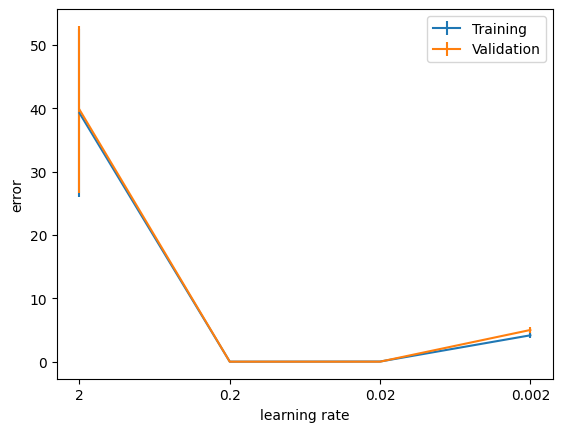

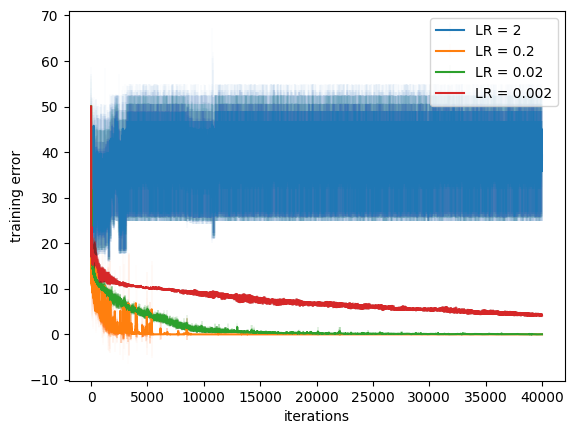

In [ ]:
plt.errorbar(np.arange(len(lrates)), plot_data_lr[0, :, :, -1].mean(axis=0), yerr=plot_data_lr[0, :, :, -1].std(axis=0), label='Training')
plt.errorbar(np.arange(len(lrates)), plot_data_lr[1, :, :, -1].mean(axis=0), yerr=plot_data_lr[0, :, :, -1].std(axis=0), label='Validation')
plt.xticks(np.arange(len(lrates)), lrates)
plt.xlabel('learning rate')
plt.ylabel('error')
plt.legend()

# Plot the evolution of the training loss for each learning rate
plt.figure()
for j, lrate in enumerate(lrates):
    x = np.arange(plot_data_lr.shape[3])
    # Mean training loss over trials
    y = plot_data_lr[0, :, j, :].mean(axis=0)
    # Standard deviation over trials
    ebar = plot_data_lr[0, :, j, :].std(axis=0)
    # Plot
    markers, caps, bars = plt.errorbar(x, y, yerr=ebar, label='LR = ' + str(lrate))
    # Make the error bars transparent
    [bar.set_alpha(0.01) for bar in bars]
plt.legend()
plt.xlabel('iterations')
plt.ylabel('training error')

### :: TASK 1.7 ::

**- Briefly discuss** the different behaviour of the training for different learning rates. How many iterations does it take to converge or does it converge at all? Which learning rate is  better and why?

######################

The graph indicates that for learning rates of lr = 2 and lr = 0.002, the error does not appear to converge. In contrast, it illustrates that as the learning rate approaches lr = 0.2 and lr = 0.02 , the error exhibits more favorable behavior. The learning rate functions as a hyperparameter that determines the extent to which the weights of the network are adjusted. A lower learning rate results in a slower progression along the gradient.

This observation elucidates why lr = 2 and lr = 0.002 do not lead to convergence; in the former case, the learning rate is excessively high, while in the latter, the gradient descent is insufficiently aggressive, resulting in persistent non-zero error even after numerous iterations.

Ultimately, the optimal learning rate is lr = 0.2, as evidenced by the second graph, which demonstrates that this rate converges more rapidly than lr = 0.02.
######################

### :: TASK 1.8 ::
**The number of hidden units:**

Set the learning rate to 0.02 and change the number of hidden units $h = \{1, 2, 5, 7, 10, 100\}$. For each of these values run the training procedure 5 times and observe the training behaviour

**-Visualize** one decision hyper-plane per number of hidden units.

**-Make one figure** where *final* error for (i) training and (ii) validation sets are superimposed. $x$-axis should be the different values of the number of hidden units, $y$-axis the error *mean* across 5 runs. Show the standard deviation with error bars and make sure to label each plot with a legend.

**-Make another figure** where *training error evolution* for each number of hidden units is superimposed. $x$-axis should be the iteration number, $y$-axis the training error *mean* across 5 runs for a given learning rate. Show the standard deviation with error bars and make sure to label each curve with a legend.

**-Briefly discuss** the different behaviours for the different numbers of hidden units.

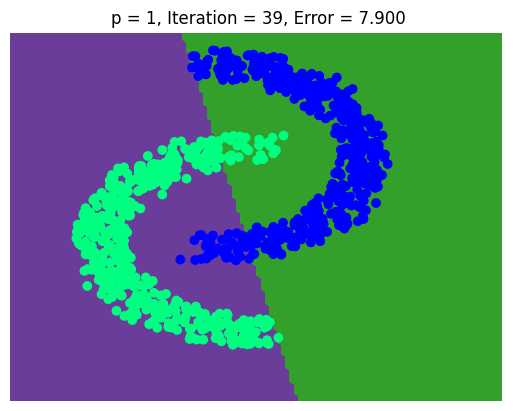

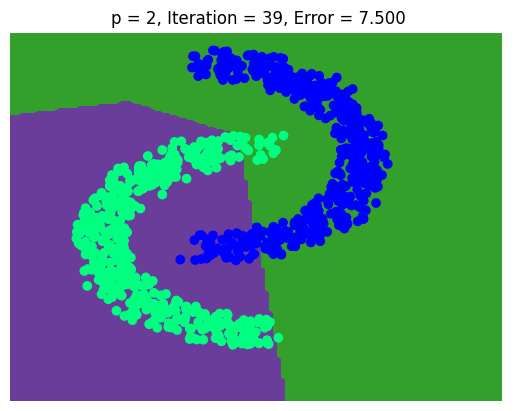

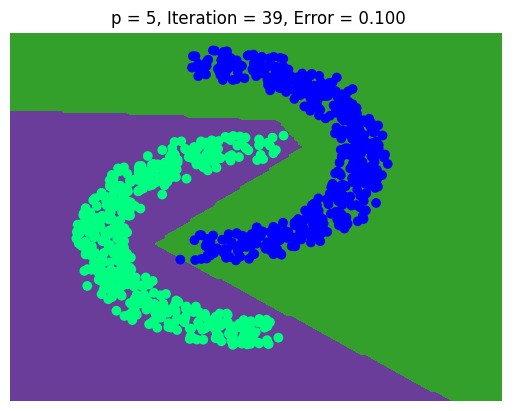

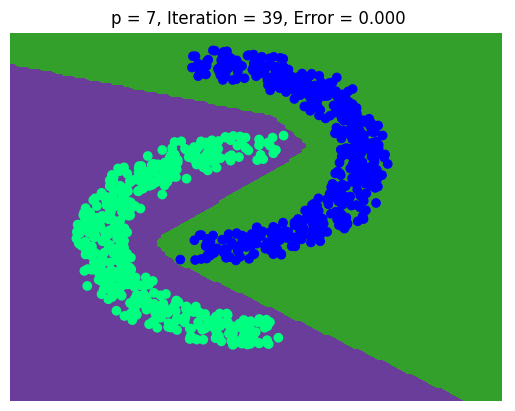

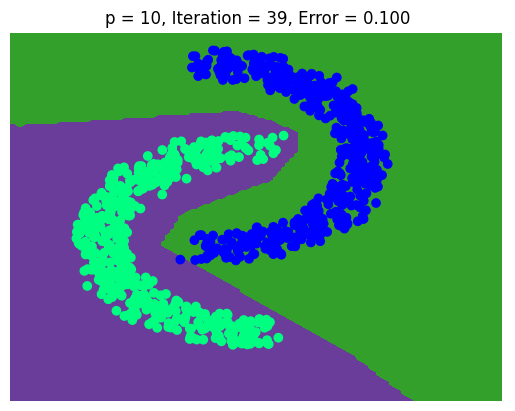

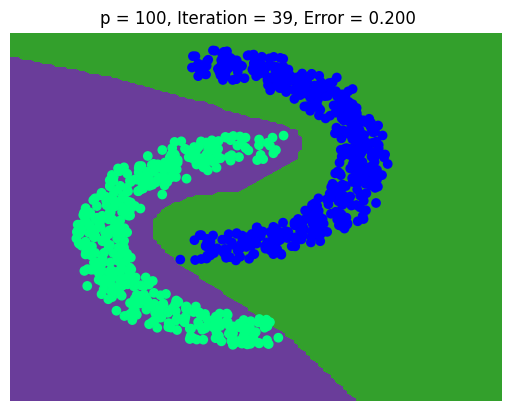

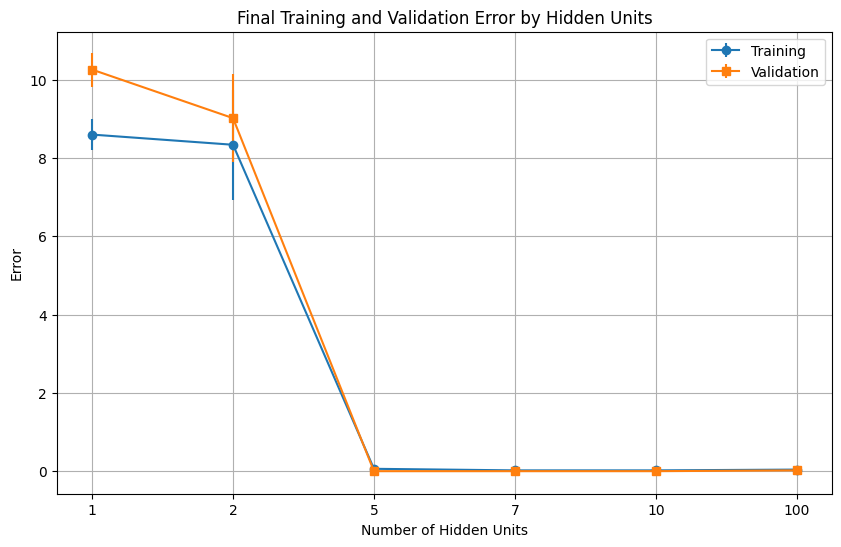

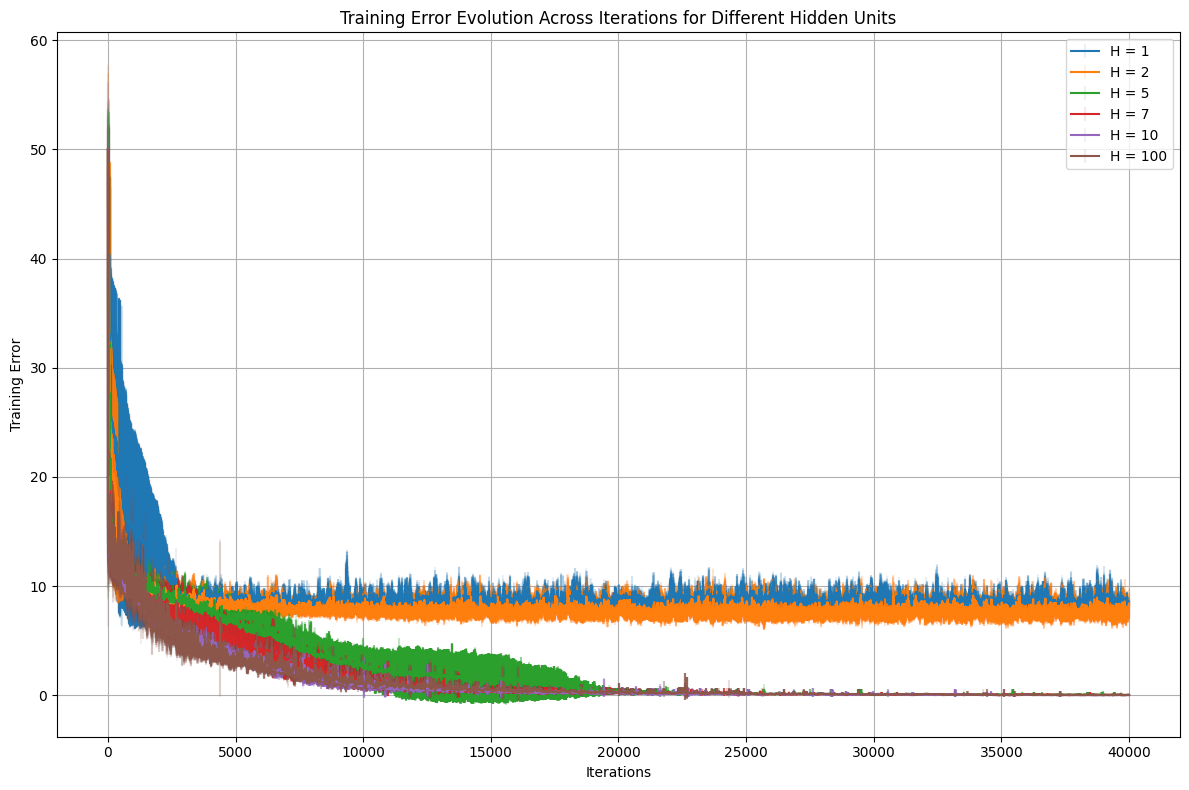

In [ ]:
##########################
# Set random seed for reproducibility
np.random.seed(123)

# Define parameters
n_epochs = 40
trials = 5
learning_rate = 0.02
hidden_units = [1, 2, 5, 7, 10, 100]
plot_data = np.zeros((2, trials, len(hidden_units), n_epochs * 1000))

# Train models with varying hidden units
for j, h in enumerate(hidden_units):
    print(f'HIDDEN UNITS = {h}')
    for i in range(trials):
        # Visualize training process selectively for certain trials
        vis_mode = 'last' if i == 2 else 'never'
        train_error, val_error = train_loop(Xtr, Ytr, Xval, Yval, h, learning_rate, vis=vis_mode, nEpochs=n_epochs)

        # Store training and validation errors
        plot_data[0, i, j, :] = train_error
        plot_data[1, i, j, :] = val_error

# Plot final training and validation errors across different hidden units
plt.figure(figsize=(10, 6))
plt.errorbar(np.arange(len(hidden_units)), plot_data[0, :, :, -1].mean(axis=0),
             yerr=plot_data[0, :, :, -1].std(axis=0), label='Training', fmt='-o')
plt.errorbar(np.arange(len(hidden_units)), plot_data[1, :, :, -1].mean(axis=0),
             yerr=plot_data[1, :, :, -1].std(axis=0), label='Validation', fmt='-s')
plt.xticks(np.arange(len(hidden_units)), hidden_units)
plt.xlabel('Number of Hidden Units')
plt.ylabel('Error')
plt.title('Final Training and Validation Error by Hidden Units')
plt.legend()
plt.grid(True)

# Plot the evolution of training loss for each hidden unit configuration
plt.figure(figsize=(12, 8))
for j, h in enumerate(hidden_units):
    x = np.arange(plot_data.shape[3])
    mean_train_loss = plot_data[0, :, j, :].mean(axis=0)
    std_train_loss = plot_data[0, :, j, :].std(axis=0)
    markers, caps, bars = plt.errorbar(x, mean_train_loss, yerr=std_train_loss, label=f'H = {h}')
    # Set transparency for error bars
    [bar.set_alpha(0.1) for bar in bars]

plt.xlabel('Iterations')
plt.ylabel('Training Error')
plt.title('Training Error Evolution Across Iterations for Different Hidden Units')
plt.legend(loc='best')
plt.grid(True)
plt.tight_layout()
plt.show()

##########################

######################

It can be observed that as the value of h increases, the training error decreases and the convergence rate accelerates.

Specifically, for lower values of h (1, 2, 5), the classifier exhibits a significant number of errors. Conversely, at higher values of h, the error approaches zero, and the convergence is more rapid as h is increased.
######################

# Part 2 - Building blocks of a CNN

This part introduces typical CNN building blocks, such as ReLU units and linear filters. For a motivation for using CNNs over fully-connected neural networks, see [[Le Cun, et al, 1998]](http://yann.lecun.com/exdb/publis/pdf/lecun-01a.pdf).


## Install PyTorch

In [ ]:
!pip install torch torchvision
import torch
print(torch.__version__)
print(torch.cuda.is_available())

2.5.0+cu121
True


## Convolution

A feed-forward neural network can be thought of as the composition of number of functions
$$
f(\mathbf{x}) = f_L(\dots f_2(f_1(\mathbf{x};\mathbf{w}_1);\mathbf{w}_2)\dots),\mathbf{w}_{L}).
$$
Each function $f_l$ takes as input a datum $\mathbf{x}_l$ and a parameter vector $\mathbf{w}_l$ and produces as output a datum $\mathbf{x}_{l+1}$. While the type and sequence of functions is usually handcrafted, the parameters $\mathbf{w}=(\mathbf{w}_1,\dots,\mathbf{w}_L)$ are *learned from data* in order to solve a target problem, for example classifying images or sounds.

In a *convolutional neural network* data and functions have additional structure. The data $\mathbf{x}_1,\dots,\mathbf{x}_n$ are images, sounds, or more in general maps from a lattice$^1$ to one or more real numbers. In particular, since the rest of the practical will focus on computer vision applications, data will be 2D arrays of pixels. Formally, each $\mathbf{x}_i$ will be a $M \times N \times K$ real array of $M \times N$ pixels and $K$ channels per pixel. Hence the first two dimensions of the array span space, while the last one spans channels. Note that only the input $\mathbf{x}=\mathbf{x}_1$ of the network is an actual image, while the remaining data are intermediate *feature maps*.

The second property of a CNN is that the functions $f_l$ have a *convolutional structure*. This means that $f_l$ applies to the input map $\mathbf{x}_l$ an operator that is *local and translation invariant*. Examples of convolutional operators are applying a bank of linear filters to $\mathbf{x}_l$.

In this part we will familiarise ourselves with a number of such convolutional and non-linear operators. The first one is the regular *linear convolution* by a filter bank. We will start by focusing our attention on a single function relation as follows:
$$
 f: \mathbb{R}^{M\times N\times K} \rightarrow \mathbb{R}^{M' \times N' \times K'},
 \qquad \mathbf{x} \mapsto \mathbf{y}.
$$

$^1$A two-dimensional *lattice* is a discrete grid embedded in $R^2$, similar for example to a checkerboard.

(384, 512, 3)


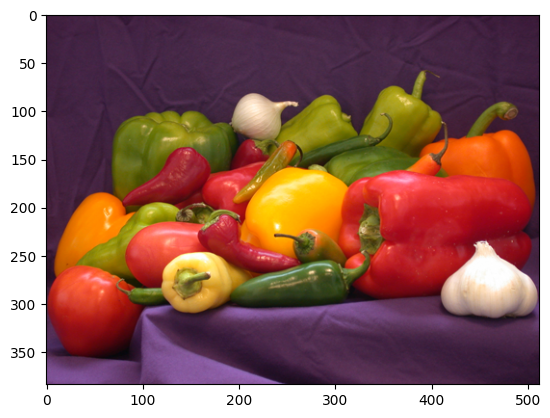

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import torch
import torchvision

# Download an example image
!wget -q http://www.di.ens.fr/willow/teaching/recvis_orig/assignment3/images/peppers.png
# Read the image
x = np.asarray(Image.open('peppers.png'))/255.0
# Print the size of x. Third dimension (=3) corresponds to the R, G, B channels
print(x.shape)
# Visualize the input x
plt.imshow(x)
# Convert to torch tensor
x = torch.from_numpy(x).permute(2, 0, 1).float()
# Prepare it as a batch
x = x.unsqueeze(0)

This should display an image of bell peppers.

Next, we create a convolutional layer with a bank of 10 filters of dimension $5 \times 5 \times 3$ whose coefficients are initialized randomly. This uses the [`torch.nn.Conv2d`](https://pytorch.org/docs/stable/nn.html#torch.nn.Conv2d) module from PyTorch:

In [ ]:
# Create a convolutional layer and a random bank of linear filters
conv = torch.nn.Conv2d(3, 10, kernel_size=5, stride=1, padding=0, bias=False)
print(conv.weight.size())

torch.Size([10, 3, 5, 5])


**Remark:** You might have noticed that the `bias` argument to the `torch.nn.Conv2d` function is the empty matrix `false`. It can be otherwise used to pass a vector of bias terms to add to the output of each filter.

Note that `conv.weight` has four dimensions, packing 10 filters. Note also that each filter is not flat, but rather a volume containing three slices. The next step is applying the filter to the image.

In [ ]:
# Apply the convolution operator
y = conv(x)
# Observe the input/output sizes
print(x.size())
print(y.size())

torch.Size([1, 3, 384, 512])
torch.Size([1, 10, 380, 508])


The variable `y` contains the output of the convolution. Note that the filters are three-dimensional. This is because they operate on a tensor $\mathbf{x}$ with $K$ channels. Furthermore, there are $K'$ such filters, generating a $K'$ dimensional map $\mathbf{y}$.

We can now visualise the output `y` of the convolution. In order to do this, use the `torchvision.utils.make_grid` function to display an image for each feature channel in `y`:

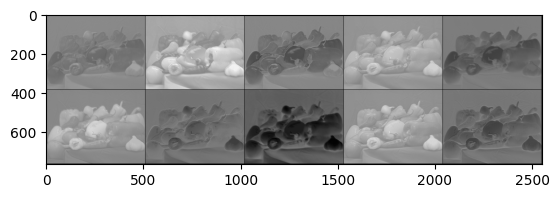

In [ ]:
# Visualize the output y
def vis_features(y):
    # Organize it into 10 grayscale images
    out = y.permute(1, 0, 2, 3)
    # Scale between [0, 1]
    out = (out - out.min().expand(out.size())) / (out.max() - out.min()).expand(out.size())
    # Create a grid of images
    out = torchvision.utils.make_grid(out, nrow=5)
    # Convert to numpy image
    out = np.transpose(out.detach().numpy(), (1, 2, 0))
    # Show
    plt.imshow(out)
    # Remove grid
    plt.gca().grid(False)

vis_features(y)

So far filters preserve the resolution of the input feature map. However, it is often useful to *downsample the output*. This can be obtained by using the `stride` option in `torch.nn.Conv2d`:

torch.Size([1, 3, 384, 512])
torch.Size([1, 10, 24, 32])


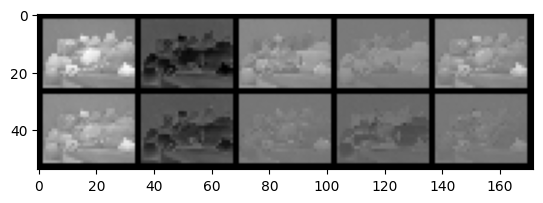

In [ ]:
# Try again, downsampling the output
conv_ds = torch.nn.Conv2d(3, 10, kernel_size=5, stride=16, padding=0, bias=False)
y_ds = conv_ds(x)
print(x.size())
print(y_ds.size())
vis_features(y_ds)

Applying a filter to an image or feature map interacts with the boundaries, making the output map smaller by an amount proportional to the size of the filters. If this is undesirable, then the input array can be padded with zeros by using the `pad` option:

torch.Size([1, 3, 384, 512])
torch.Size([1, 10, 384, 512])


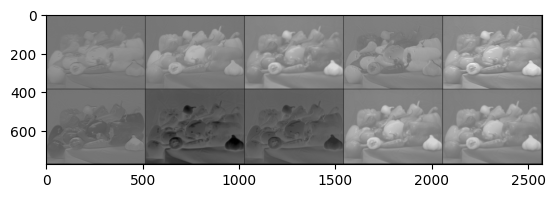

In [ ]:
# Try padding
conv_pad = torch.nn.Conv2d(3, 10, kernel_size=5, stride=1, padding=2, bias=False)
y_pad = conv_pad(x)
print(x.size())
print(y_pad.size())
vis_features(y_pad)

In order to consolidate what has been learned so far, we will now design a filter by hand:


torch.Size([1, 3, 384, 512])
torch.Size([1, 1, 384, 512])


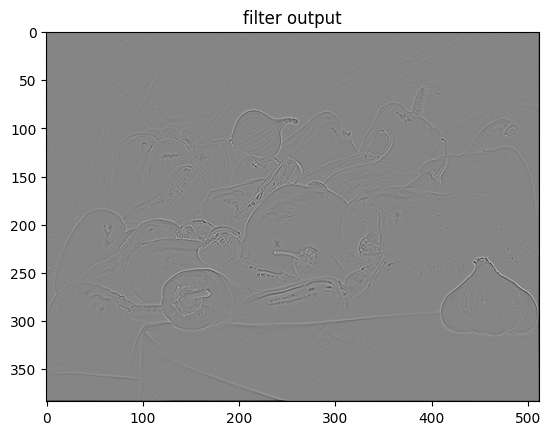

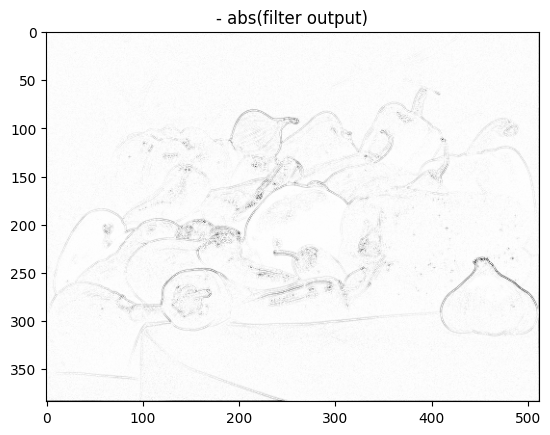

In [ ]:
w = torch.FloatTensor([[0,  1, 0 ],
                      [1, -4, 1 ],
                      [0,  1, 0 ]])
w = w.repeat(3, 1).reshape(1, 3, 3, 3)
conv_lap = torch.nn.Conv2d(3, 3, kernel_size=3, stride=1, padding=1, bias=False)
conv_lap.weight = torch.nn.Parameter(w)
y_lap = conv_lap(x)
print(x.size())
print(y_lap.size())

plt.figure()
vis_features(y_lap)
plt.title('filter output')

plt.figure()
vis_features(-torch.abs(y_lap))
plt.title('- abs(filter output)') ;


### :: TASK 2.1 ::
* i. What filter have we implemented?
* ii. How are the RGB colour channels processed by this filter?
* iii. What image structure are detected?

######################

### What filter have we implemented?

This filter is used for edge detection by highlighting regions in the image where there is a rapid change in intensity. It detects edges by computing the second-order derivatives, which helps to identify areas of high contrast, often corresponding to edges.

### How are the RGB color channels processed by this filter?

The Laplacian filter is applied independently to each of the RGB color channels. The filter is repeated across all three channels so that each channel undergoes the same edge detection process. This means the edges are detected separately for each color channel, and the resulting output preserves the color information at the detected edges.

### What image structure is detected?

These edges typically representcommonly delineate boundaries between objects, such as vegetebables, and differens well as distinct color regions within the image.

######################


## Non-linear activation functions

The simplest non-linearity is obtained by following a linear filter by a *non-linear activation function*, applied identically to each component (i.e. point-wise) of a feature map. The simplest such function is the *Rectified Linear Unit (ReLU)*
$$
  y_{ijk} = \max\{0, x_{ijk}\}.
$$
This function is implemented by [`torch.nn.ReLU()`](https://pytorch.org/docs/stable/nn.html#torch.nn.ReLU). Run the code below and understand what the filter $\mathbf{w}$ is doing.


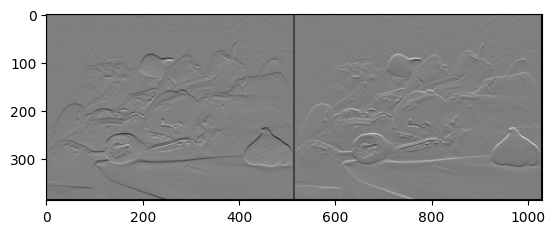

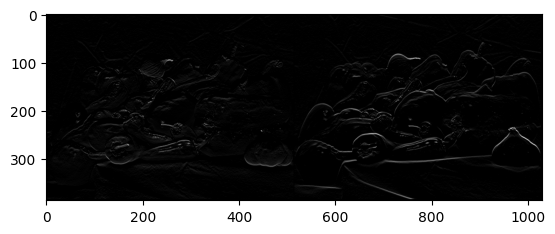

In [ ]:
w = torch.FloatTensor([[1], [0], [-1]]).repeat(1, 3, 1, 1)
w = torch.cat((w, -w), 0)

conv = torch.nn.Conv2d(3, 2, kernel_size=(3, 1), stride=1, padding=0, bias=False)
conv.weight = torch.nn.Parameter(w)
relu = torch.nn.ReLU()

y = conv(x)
z = relu(y)

plt.figure()
vis_features(y)
plt.figure()
vis_features(z)

## Pooling
There are several other important operators in a CNN. One of them is *pooling*.  A pooling operator operates on individual feature channels, coalescing nearby feature values into one by the application of a suitable operator. Common choices include max-pooling (using the max operator) or sum-pooling (using summation). For example, *max-pooling* is defined as:
$$
   y_{ijk} = \max \{ y_{i'j'k} : i \leq i' < i+p, j \leq j' < j + p \}
$$
Max-pooling is implemented by [`torch.nn.MaxPool2d()`](https://pytorch.org/docs/stable/nn.html#torch.nn.MaxPool2d).

### :: TASK 2.2 ::

Run the code below to try max-pooling. Look at the resulting image. Can you interpret the result?

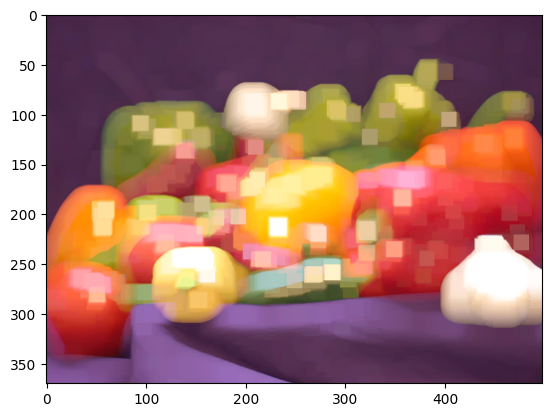

In [ ]:
mp = torch.nn.MaxPool2d(15, stride=1)
y = mp(x)
plt.imshow(y.squeeze().permute(1, 2, 0).numpy())
plt.gca().grid(False)

######################

Max-pooling reduces spatial resolution by retaining only the maximum pixel value within each kernel window. This process produces a blocky, pixelated effect in the resulting image.

By selecting the brightest or most prominent pixel values from each area, max-pooling enhances certain features while diminishing finer details. This technique allows for a focus on broader patterns or colors, discarding small variations. The outcome is a simplified, coarser version of the original image, characterized by larger, more uniform patches of color, resulting in an abstract, pixelated appearance.

######################

# Part 3 - Training a CNN

This part is an introduction to using PyTorch for training simple neural net models. CIFAR-10 dataset will be used.

## Imports

In [ ]:
from __future__ import print_function
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.autograd import Variable

## Parameters

The default values for the learning rate, batch size and number of epochs are given in the "options" cell of this notebook.
Unless otherwise specified, use the default values throughout this assignment.

In [ ]:
batch_size = 64   # input batch size for training
epochs = 10       # number of epochs to train
lr = 0.01         # learning rate

## Warmup





It is always good practice to visually inspect your data before trying to train a model, since it lets you check for problems and get a feel for the task at hand.

CIFAR-10 is a dataset of 60,000 color images (32 by 32 resolution) across 10 classes
(airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck).
The train/test split is 50k/10k.

In [ ]:
# Data Loading
# Warning: this cell might take some time when you run it for the first time,
#          because it will download the dataset from the internet
dataset = 'cifar10'
data_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])
trainset = datasets.CIFAR10(root='.', train=True, download=True, transform=data_transform)
testset = datasets.CIFAR10(root='.', train=False, download=True, transform=data_transform)

train_loader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=0)
test_loader  = torch.utils.data.DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=0)

100%|██████████| 170M/170M [00:18<00:00, 9.22MB/s]


Extracting ./cifar-10-python.tar.gz to .
Files already downloaded and verified


### :: TASK 3.1 ::

Use `matplotlib` and ipython notebook's visualization capabilities to display some of these images. Display 5 images from the dataset together with their category label. [See this PyTorch tutorial page](http://pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html#sphx-glr-beginner-blitz-cifar10-tutorial-py) for hints on how to achieve this.

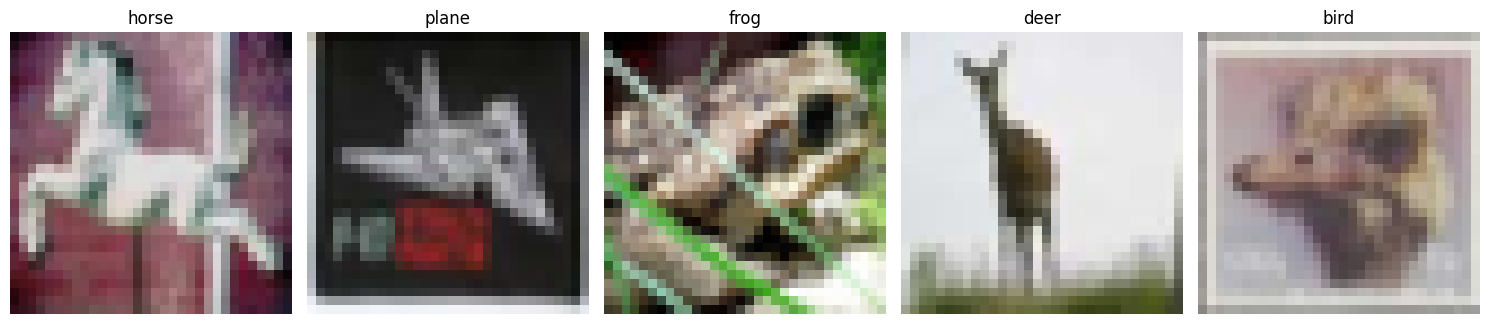

In [ ]:
##########################
# Define the class labels
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

# Get a batch of images and labels
images, labels = next(iter(train_loader))

# Display the first 5 images from the batch with their corresponding labels
plt.figure(figsize=(15, 5))

for i, (image, label) in enumerate(zip(images[:5], labels[:5])):
    # Unnormalize the image for display
    img = image / 2 + 0.5  # Assuming the image was normalized with mean=0.5 and std=0.5
    npimg = img.numpy()

    # Display each image in a subplot
    plt.subplot(1, 5, i + 1)
    plt.imshow(np.transpose(npimg, (1, 2, 0)))  # Convert from (C, H, W) to (H, W, C)
    plt.title(classes[label], fontsize=12)
    plt.axis('off')  # Hide axes for a cleaner display

plt.tight_layout()
plt.show()


##########################



## Training a Convolutional Network on CIFAR-10




Start by running the provided training code below. By default it will train on CIFAR-10 for 10 epochs (passes through the training data) with a single layer network. The loss function [cross_entropy](http://pytorch.org/docs/master/nn.html?highlight=cross_entropy#torch.nn.functional.cross_entropy) computes a Logarithm of the Softmax on the output of the neural network, and then computes the negative log-likelihood w.r.t. the given `target`. Note the decrease in training loss and corresponding decrease in validation errors.

In [ ]:
def train(epoch, network):
    network.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        optimizer.zero_grad()
        output = network(data)
        loss = F.cross_entropy(output, target)
        loss.backward()
        optimizer.step()
        if batch_idx % 100 == 0:
            print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
                epoch, batch_idx * len(data), len(train_loader.dataset),
                100. * batch_idx / len(train_loader), loss.item()))

def test(network):
    network.eval()
    test_loss = 0
    correct = 0
    for data, target in test_loader:
        output = network(data)
        test_loss += F.cross_entropy(output, target, size_average=False).item() # sum up batch loss
        pred = output.data.max(1, keepdim=True)[1] # get the index of the max log-probability
        correct += pred.eq(target.data.view_as(pred)).cpu().sum()

    test_loss /= len(test_loader.dataset)
    print('\nTest set: Average loss: {:.4f}, Accuracy: {}/{} ({:.0f}%)\n'.format(
        test_loss, correct, len(test_loader.dataset),
        100. * correct / len(test_loader.dataset)))

In [ ]:
# Single layer network architecture

class Net(nn.Module):
    def __init__(self, num_inputs, num_outputs):
        super(Net, self).__init__()
        self.linear = nn.Linear(num_inputs, num_outputs)
        self.num_inputs = num_inputs

    def forward(self, input):
        input = input.view(-1, self.num_inputs) # reshape input to batch x num_inputs
        output = self.linear(input)
        return output

In [ ]:
# Train
network = Net(3072, 10)
optimizer = optim.SGD(network.parameters(), lr=lr)
for epoch in range(1, 11):
    train(epoch, network)
    test(network)

Train Epoch: 1 [0/50000 (0%)]	Loss: 2.297843
Train Epoch: 1 [6400/50000 (13%)]	Loss: 1.829984
Train Epoch: 1 [12800/50000 (26%)]	Loss: 1.911536
Train Epoch: 1 [19200/50000 (38%)]	Loss: 1.660641
Train Epoch: 1 [25600/50000 (51%)]	Loss: 1.751018
Train Epoch: 1 [32000/50000 (64%)]	Loss: 1.633502
Train Epoch: 1 [38400/50000 (77%)]	Loss: 1.752128
Train Epoch: 1 [44800/50000 (90%)]	Loss: 1.868580


/usr/local/lib/python3.10/dist-packages/torch/nn/_reduction.py:51: UserWarning: size_average and reduce args will be deprecated, please use reduction='sum' instead.
  warnings.warn(warning.format(ret))



Test set: Average loss: 1.7704, Accuracy: 3933/10000 (39%)

Train Epoch: 2 [0/50000 (0%)]	Loss: 1.930708
Train Epoch: 2 [6400/50000 (13%)]	Loss: 2.066434
Train Epoch: 2 [12800/50000 (26%)]	Loss: 1.809036
Train Epoch: 2 [19200/50000 (38%)]	Loss: 1.869297
Train Epoch: 2 [25600/50000 (51%)]	Loss: 1.840135
Train Epoch: 2 [32000/50000 (64%)]	Loss: 1.550576
Train Epoch: 2 [38400/50000 (77%)]	Loss: 1.657467
Train Epoch: 2 [44800/50000 (90%)]	Loss: 1.969668

Test set: Average loss: 1.7584, Accuracy: 3952/10000 (40%)

Train Epoch: 3 [0/50000 (0%)]	Loss: 2.079998
Train Epoch: 3 [6400/50000 (13%)]	Loss: 1.850994
Train Epoch: 3 [12800/50000 (26%)]	Loss: 1.465469
Train Epoch: 3 [19200/50000 (38%)]	Loss: 1.761649
Train Epoch: 3 [25600/50000 (51%)]	Loss: 1.748258
Train Epoch: 3 [32000/50000 (64%)]	Loss: 1.614884
Train Epoch: 3 [38400/50000 (77%)]	Loss: 1.816428
Train Epoch: 3 [44800/50000 (90%)]	Loss: 1.682437

Test set: Average loss: 1.7419, Accuracy: 3983/10000 (40%)

Train Epoch: 4 [0/50000 (0%)]

### :: TASK 3.2 ::

Add code to create a convolutional network architecture as below.

  - Convolution with 5 by 5 filters, 16 feature maps + Tanh nonlinearity.
  - 2 by 2 max pooling.
  - Convolution with 5 by 5 filters, 128 feature maps + Tanh nonlinearity.
  - 2 by 2 max pooling.
  - Flatten to vector.
  - Linear layer with 64 hidden units + Tanh nonlinearity.
  - Linear layer to 10 output units.

In [ ]:
class ConvNet(nn.Module):
    def __init__(self):
        super(ConvNet, self).__init__()

        # First convolutional layer: 5x5 filters, 16 feature maps, Tanh activation
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=5)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Second convolutional layer: 5x5 filters, 128 feature maps, Tanh activation
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=128, kernel_size=5)

        # Fully connected layers
        self.fc1 = nn.Linear(128 * 5 * 5, 64)  # Flattened input, 64 hidden units
        self.fc2 = nn.Linear(64, 10)           # Output layer with 10 units (for 10 classes)

    def forward(self, x):
        # First convolutional layer + Tanh + pooling
        x = self.pool(torch.tanh(self.conv1(x)))

        # Second convolutional layer + Tanh + pooling
        x = self.pool(torch.tanh(self.conv2(x)))

        # Flatten to vector
        x = x.view(-1, 128 * 5 * 5)

        # Fully connected layers with Tanh activations
        x = torch.tanh(self.fc1(x))
        x = self.fc2(x)  # No activation for the final layer (e.g., used with CrossEntropyLoss)

        return x

### :: TASK 3.3 ::

Some of the functions in a CNN must be non-linear. Why?





######################

 Without non-linear activation functions, a neural network would only be capable of learning linear relationships, as stacked linear transformations would still result in a linear transformation. Non-linear functions enable the model to learn complex, non-linear patterns, which are crucial for tasks like image classification and object detection.

######################

### :: TASK 3.4 ::
Train the CNN for 20 epochs on the CIFAR-10 training set.



In [ ]:
# Train
network=ConvNet()
optimizer = optim.SGD(network.parameters(), lr=lr)
for epoch in range(1, 21):
    train(epoch, network)
    test(network)

Train Epoch: 1 [0/50000 (0%)]	Loss: 2.315909
Train Epoch: 1 [6400/50000 (13%)]	Loss: 2.181594
Train Epoch: 1 [12800/50000 (26%)]	Loss: 1.919746
Train Epoch: 1 [19200/50000 (38%)]	Loss: 1.836190
Train Epoch: 1 [25600/50000 (51%)]	Loss: 1.919734
Train Epoch: 1 [32000/50000 (64%)]	Loss: 1.993450
Train Epoch: 1 [38400/50000 (77%)]	Loss: 1.900129
Train Epoch: 1 [44800/50000 (90%)]	Loss: 1.672459

Test set: Average loss: 1.7861, Accuracy: 3763/10000 (38%)

Train Epoch: 2 [0/50000 (0%)]	Loss: 1.875293
Train Epoch: 2 [6400/50000 (13%)]	Loss: 1.749140
Train Epoch: 2 [12800/50000 (26%)]	Loss: 1.745973
Train Epoch: 2 [19200/50000 (38%)]	Loss: 1.814007
Train Epoch: 2 [25600/50000 (51%)]	Loss: 1.638781
Train Epoch: 2 [32000/50000 (64%)]	Loss: 1.584833
Train Epoch: 2 [38400/50000 (77%)]	Loss: 1.562614
Train Epoch: 2 [44800/50000 (90%)]	Loss: 1.522227

Test set: Average loss: 1.5995, Accuracy: 4317/10000 (43%)

Train Epoch: 3 [0/50000 (0%)]	Loss: 1.503791
Train Epoch: 3 [6400/50000 (13%)]	Loss: 1.529

### :: TASK 3.5 ::
Plot the first convolutional layer weights as images after the last epoch. (Hint threads: [#1](https://discuss.pytorch.org/t/understanding-deep-network-visualize-weights/2060/2?u=smth) [#2](https://github.com/pytorch/vision#utils) )


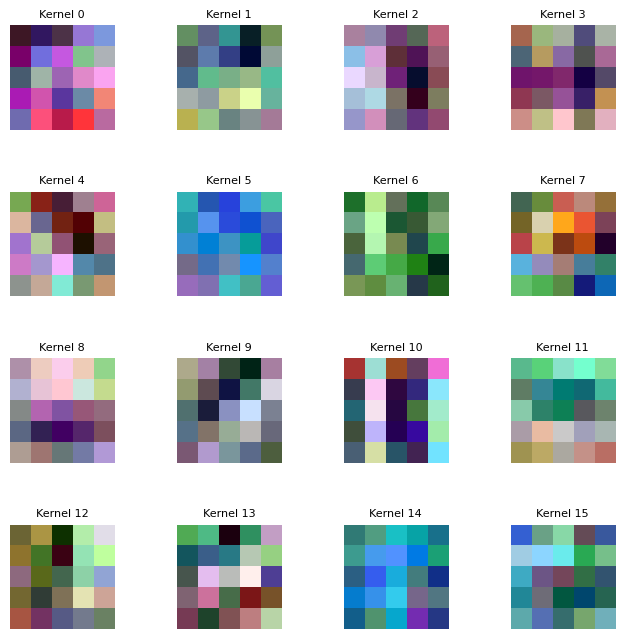

In [ ]:
def plot_kernels(tensor, num_cols=6):
    if not tensor.ndim == 4:
        raise Exception("Assumes a 4D tensor")
    if not tensor.shape[-1] == 3:
        raise Exception("Last dimension needs to be 3 to plot")

    num_kernels = tensor.shape[0]
    num_rows = 1 + num_kernels // num_cols
    fig = plt.figure(figsize=(2 * num_cols, 2 * num_rows))

    for i in range(num_kernels):
        ax1 = fig.add_subplot(num_rows, num_cols, i + 1)

        # Normalize and plot the kernel
        ax1.imshow((tensor[i] - tensor[i].min()) / (tensor[i].max() - tensor[i].min()))
        ax1.axis('off')

        # Add title with kernel index
        ax1.set_title(f"Kernel {i}", fontsize=8)

    plt.subplots_adjust(wspace=0.4, hspace=0.6)
    plt.show()

# Assuming `network` is the model
mm = network.double()
layer1 = [i for i in mm.children()][0]
tensor = layer1.weight.cpu().data.numpy()
tensor = np.transpose(tensor, (0, 2, 3, 1))
plot_kernels(tensor, num_cols=4)


### :: TASK 3.6 ::

What is the dimensionality of the weights at each layer? How many parameters are there in total in this CNN architecture?

######################

Here's an analysis of the dimensionality of the weights and the calculation of the total parameters in the CNN architecture:

1. **First Convolutional Layer**:
   - Weight dimensions: \((16, 3, 5, 5)\)
   - This means there are 16 filters, each with 3 channels (for RGB), and each filter is \(5 \times 5\) in spatial dimensions.
   - Number of parameters (without bias): \(16 * 3 * 5 * 5 = 1200\)

2. **Second Convolutional Layer**:
   - Weight dimensions: \((128, 16, 5, 5)\)
   - There are 128 filters, each with 16 input channels (from the previous layer), and each filter is \(5* 5\) in size.
   - Number of parameters (without bias): \(128 * 16 * 5 * 5 = 51200\)

3. **First Fully Connected (Linear) Layer**:
   - Weight dimensions after flattening: \((64, 3200)\), where \(3200\) is the flattened size of the feature maps from the last convolutional layer.
   - Number of parameters (without bias): \(64 * 3200 = 204800\)

4. **Last Fully Connected (Linear) Layer**:
   - Weight dimensions: \((10, 64)\)
   - Number of parameters (without bias): \(10 * 64 = 640\)

5. **Adding Bias Terms**:
   - Each filter or neuron typically has a corresponding bias term, so we add bias parameters:
     - First conv layer: \(16\) biases
     - Second conv layer: \(128\) biases
     - First linear layer: \(64\) biases
     - Last linear layer: \(10\) biases

6. **Total Number of Parameters**:
   - Calculating the total:
$$  16*3*5*5 + 128*16*5*5 + (3200+1)*64 + (64+1)*10 = 257914\text{ parameters} $$

So, the CNN architecture has a total of **257,914 parameters** including both weights and biases.

######################



## Useful resources

  - [PyTorch tutorial](http://pytorch.org/tutorials/beginner/blitz/neural_networks_tutorial.html#sphx-glr-beginner-blitz-neural-networks-tutorial-py)
  - [MNIST example](https://github.com/pytorch/examples/tree/master/mnist)

## AUTHORSHIP STATEMENT

I declare that the preceding work was the sole result of my own effort and that I have not used any code or results from third-parties.

RAMI Ilias